# Group Exercise E3: Reactor Sizing via Levenspiel Plots
**Course 28342: Reaktionsteknik**

*Week 3 Exercise 3*

This notebook demonstrates how to size catalytic reactors using rate-conversion data. We will compare single reactor setups against an optimized series configuration.

### Reference Materials
*   Exercise Description: **"Grupperegningsopgave E3.pdf"**[cite: 5]
*   Official Solutions: **"Løsning E3.pdf"**[cite: 6]

### Core Concepts
For catalytic reactors, the "size" is defined by the **weight of catalyst ($W$)**.
*   **CSTR (Mixed Flow):** $W = \frac{F_{A0}}{-r'_A} \cdot X$[cite: 6]
*   **PBR (Plug Flow):** $W = \int_{0}^{X} \frac{F_{A0}}{-r'_A} dX$[cite: 6]

This notebook sizes a catalytic reactor system for the adiabatic reaction $A \rightarrow B$ to achieve **90% conversion**. We will compare:
1. A single **CSTR**
2. A single **PBR**
3. An **optimized series** (CSTR followed by PBR)

---
## Problem A: Single Reactor Comparison
We aim for a total conversion of $X = 0.9$ for an exothermic reaction[cite: 5].


### 1. Single CSTR Sizing
From the Levenspiel plot, at $X = 0.9$, the value on the y-axis ($\frac{F_{A0}}{-r'_A}$) is **42 kg catalyst**[cite: 6].


The CSTR design equation for a packed bed (catalytic) reactor is:
$$W_{CSTR} = \frac{F_{A0}}{-r_A'(X_f)} \cdot X_f$$

Graphically this is the **rectangle** with width $X_f$ and height $L(X_f)$.



In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Digitized data from Figure P2-12
# y-axis: F_A0 / (-r_A') [kg catalyst]
X_data = np.array([0.0,  0.3,  0.5,  0.6,  0.7,  0.8,  0.9])
L_data = np.array([60.0, 22.0, 18.0, 20.0, 22.0, 30.0, 42.0])

# Smooth cubic spline for high-quality visualization
cs = CubicSpline(X_data, L_data)
X_fine = np.linspace(0, 0.9, 1000)
L_fine = cs(X_fine)

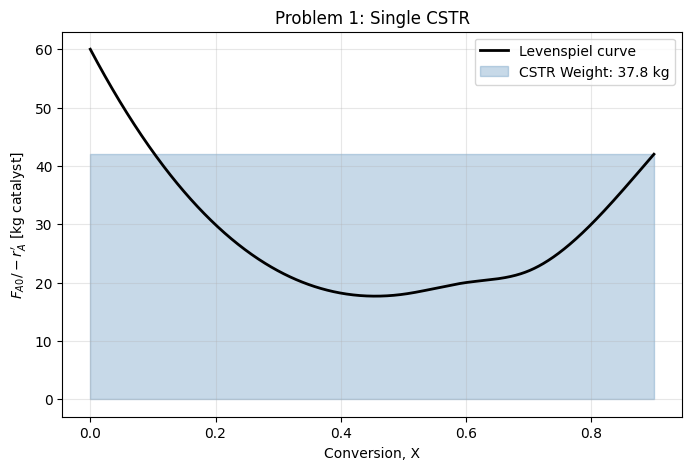

In [13]:
X_f = 0.9
L_exit = 42.0 # Exit rate at X = 0.9
W_CSTR = L_exit * X_f

plt.figure(figsize=(8, 5))
plt.plot(X_fine, L_fine, 'k-', lw=2, label='Levenspiel curve')
# CSTR Area: A rectangle with height L_exit[cite: 7]
plt.fill_between([0, X_f], 0, L_exit, alpha=0.3, color='steelblue', label=f'CSTR Weight: {W_CSTR:.1f} kg')
plt.xlabel('Conversion, X')
plt.ylabel("$F_{A0}/-r_A'$ [kg catalyst]")
plt.title('Problem 1: Single CSTR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2. Single PBR Sizing
To find the catalyst weight for a PBR (packed bed reactor), we use the following design equation:
$$W_{PBR} = F_{A0}\int_0^{X_f} \frac{dX}{-r_A'} = \int_0^{X_f} L(X)\,dX$$

Graphically this is the **area under the Levenspiel curve**.

The integral is evaluated numerically using the **trapezoidal rule**:
$$\int_{X_1}^{X_2} L\,dX \approx (X_2 - X_1)\cdot\frac{L(X_1) + L(X_2)}{2}$$

The curve is split into 3 segments using the data points from the graph.

/tmp/ipykernel_13836/1377076494.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  W_PBR = np.trapz(L_pbr, X_pbr)


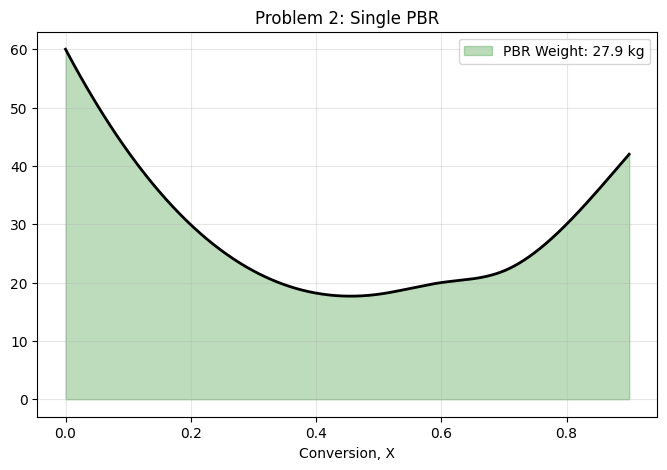

In [14]:
# Trapezoidal segments for Single PBR (X: 0->0.3, 0.3->0.6, 0.6->0.9)[cite: 7]
X_pbr = np.array([0.0, 0.3, 0.6, 0.9])
L_pbr = np.array([60.0, 22.0, 20.0, 42.0])
W_PBR = np.trapz(L_pbr, X_pbr)

plt.figure(figsize=(8, 5))
plt.plot(X_fine, L_fine, 'k-', lw=2)
# PBR Area: Area under the curve[cite: 7]
plt.fill_between(X_fine, 0, L_fine, alpha=0.3, color='forestgreen', label=f'PBR Weight: {W_PBR:.1f} kg')
plt.xlabel('Conversion, X')
plt.title('Problem 2: Single PBR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Problem 3: Optimization - Reactors in Series
To minimize the total catalyst mass, we look for the "valley" in the Levenspiel plot[cite: 6].
*   **Stage 1:** A CSTR handles the initial conversion up to $X = 0.5$, where the reaction rate is highest (y-value is lowest at 18)[cite: 6].
*   **Stage 2:** A PBR handles the conversion from $X = 0.5$ to $X = 0.9$[cite: 6].

/tmp/ipykernel_13836/1457823567.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  W_PBR_opt = np.trapz(L_pbr2, X_pbr2)


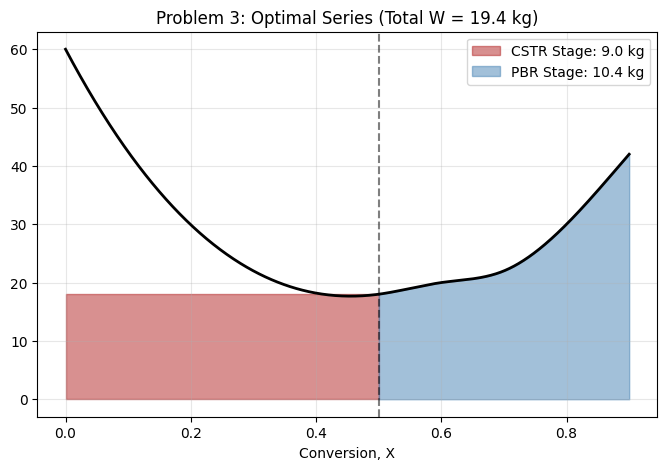

In [15]:
# CSTR Stage: 0 to 0.5[cite: 7]
X_sw = 0.5
L_sw = 18.0
W_CSTR_opt = L_sw * X_sw

# PBR Stage: 0.5 to 0.9[cite: 7]
X_pbr2 = np.array([0.5, 0.7, 0.9])
L_pbr2 = np.array([18.0, 22.0, 42.0])
W_PBR_opt = np.trapz(L_pbr2, X_pbr2)

plt.figure(figsize=(8, 5))
plt.plot(X_fine, L_fine, 'k-', lw=2)

# CSTR Area (Rectangle at height 18)[cite: 7]
plt.fill_between([0, X_sw], 0, L_sw, color='firebrick', alpha=0.5, label=f'CSTR Stage: {W_CSTR_opt:.1f} kg')

# PBR Area (Area under curve from 0.5 to 0.9)[cite: 7]
X_p2_fill = np.linspace(X_sw, 0.9, 100)
plt.fill_between(X_p2_fill, 0, cs(X_p2_fill), color='steelblue', alpha=0.5, label=f'PBR Stage: {W_PBR_opt:.1f} kg')

plt.axvline(X_sw, color='k', linestyle='--', alpha=0.5)
plt.title(f'Problem 3: Optimal Series (Total W = {W_CSTR_opt + W_PBR_opt:.1f} kg)')
plt.xlabel('Conversion, X')
plt.legend()
plt.grid(alpha=0.3)
plt.show()